# Importacion de Modelos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
import urllib.request

In [2]:
current_path = os.getcwd()
print(current_path)

c:\Users\Lucas\Documents


In [3]:
def descargar_modelos_pkl(diccionario_links, carpeta_destino="modelos_descargados"):
    """
    Descarga archivos .pkl desde una lista de URLs.

    :param diccionario_links: Un diccionario donde la clave es el nombre que quieres
                              darle al archivo (ej: 'modelo_gbm') y el valor es la URL.
    :param carpeta_destino: Nombre de la carpeta donde se guardarán los archivos.
    """
    # Crear la carpeta de destino si no existe
    if not os.path.exists(carpeta_destino):
        os.makedirs(carpeta_destino)
        print(f"📁 Carpeta '{carpeta_destino}' creada con éxito.")

    # Recorrer el diccionario y descargar cada archivo
    for nombre, url in diccionario_links.items():
        # Asegurarse de que el nombre termine en .pkl
        if not nombre.endswith('.pkl'):
            nombre += '.pkl'

        ruta_final = os.path.join(carpeta_destino, nombre)
        print(f"⏳ Descargando {nombre} desde {url}...")

        try:
            # Descargar y guardar el archivo
            urllib.request.urlretrieve(url, ruta_final)
            print(f"✅ ¡Descarga completada! Guardado en: {ruta_final}\n")
        except Exception as e:
            print(f"❌ Error al descargar {nombre}: {e}\n")

# ==========================================
# EJEMPLO DE USO:
# ==========================================

links = {
    "M1_logistica": "https://anfora.netlify.app/datos/v6/modelos/M1_logistica.pkl",
    "M2_random_forest": "https://anfora.netlify.app/datos/v6/modelos/M2_random_forest.pkl",
    "M3_gbm_completo": "https://anfora.netlify.app/datos/v6/modelos/M3_gbm_completo.pkl",
    "M4_gbm_moderado": "https://anfora.netlify.app/datos/v6/modelos/M4_gbm_moderado.pkl",
    "M5_naive_bayes": "https://anfora.netlify.app/datos/v6/modelos/M5_naive_bayes.pkl"
}

# Llamas a la función pasando tu diccionario
descargar_modelos_pkl(links, carpeta_destino="v6/modelos")

⏳ Descargando M1_logistica.pkl desde https://anfora.netlify.app/datos/v6/modelos/M1_logistica.pkl...
✅ ¡Descarga completada! Guardado en: v6/modelos\M1_logistica.pkl

⏳ Descargando M2_random_forest.pkl desde https://anfora.netlify.app/datos/v6/modelos/M2_random_forest.pkl...
✅ ¡Descarga completada! Guardado en: v6/modelos\M2_random_forest.pkl

⏳ Descargando M3_gbm_completo.pkl desde https://anfora.netlify.app/datos/v6/modelos/M3_gbm_completo.pkl...
✅ ¡Descarga completada! Guardado en: v6/modelos\M3_gbm_completo.pkl

⏳ Descargando M4_gbm_moderado.pkl desde https://anfora.netlify.app/datos/v6/modelos/M4_gbm_moderado.pkl...
✅ ¡Descarga completada! Guardado en: v6/modelos\M4_gbm_moderado.pkl

⏳ Descargando M5_naive_bayes.pkl desde https://anfora.netlify.app/datos/v6/modelos/M5_naive_bayes.pkl...
✅ ¡Descarga completada! Guardado en: v6/modelos\M5_naive_bayes.pkl



¡Modelo cargado exitosamente!


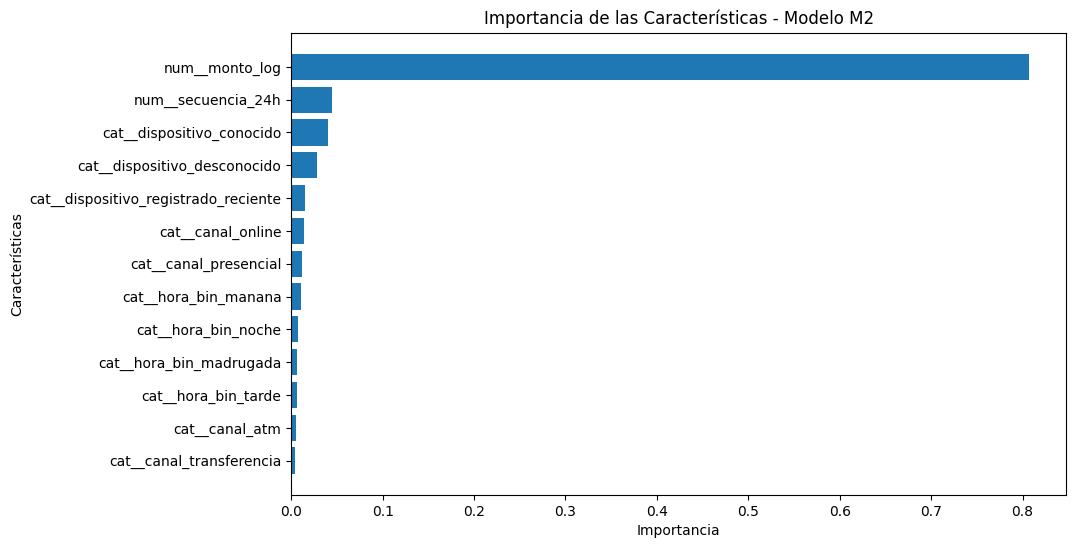

¡Modelo cargado exitosamente!


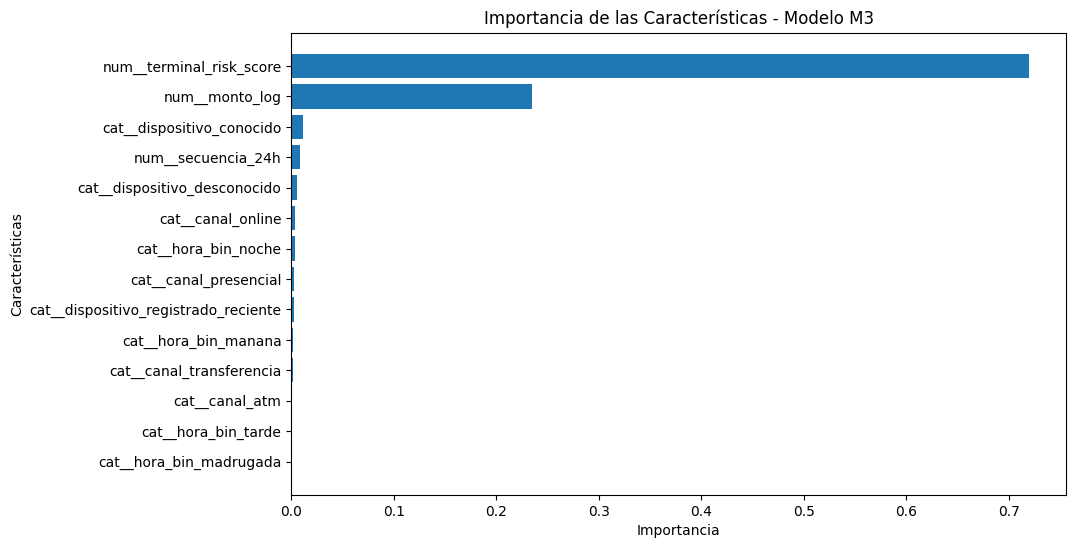

¡Modelo cargado exitosamente!


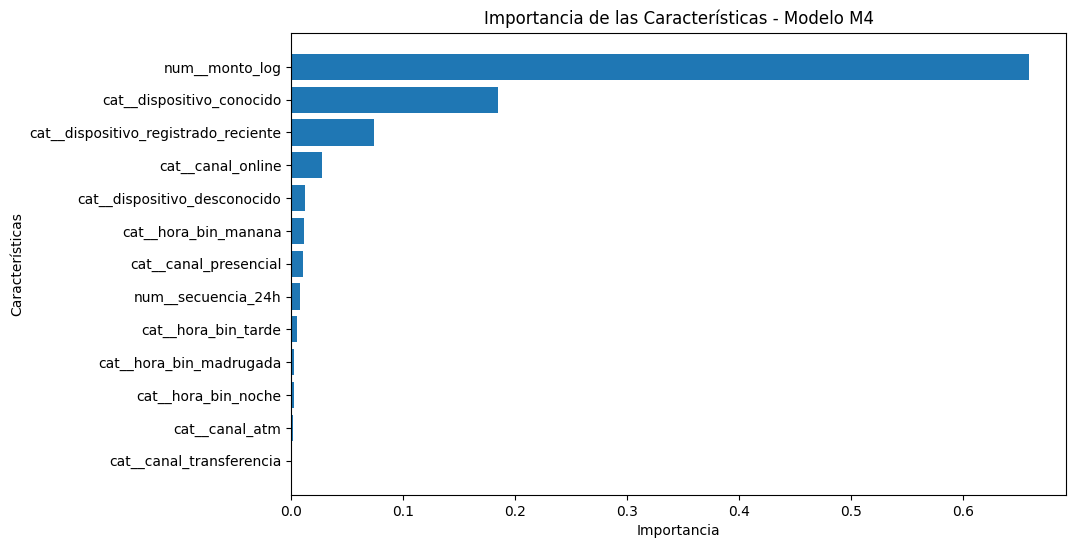

In [4]:
# Definir los nombres de los archivos que quieres buscar
nombres_modelos = [
    'M2_random_forest.pkl',
    'M3_gbm_completo.pkl',
    'M4_gbm_moderado.pkl'
]

modelos = [os.path.join(current_path, 'v6', 'modelos', nombre) for nombre in nombres_modelos]

nombre_modelos = ['M2', 'M3', 'M4']

for m, n in zip(modelos, nombre_modelos):
    ruta_modelo = m
    nombre_modelo = n

    try:
        modelo = joblib.load(ruta_modelo)
        print("¡Modelo cargado exitosamente!")

    except FileNotFoundError:
        print(f"Error: No se encontró el archivo en la ruta '{ruta_modelo}'. Asegúrate de que el nombre y la ubicación sean correctos.")
    except Exception as e:
        print(f"Ocurrió un error al cargar el modelo: {e}")

    # 1. Asegúrate de tener la lista con los nombres de tus columnas (features)
    nombres_columnas = modelo["pipeline"]['pre'].get_feature_names_out().tolist()

    # 2. Extraer la importancia del modelo cargado
    importancias = modelo["pipeline"]["clf"].feature_importances_

    # 3. Crear un DataFrame para ordenarlas fácilmente
    df_importancia = pd.DataFrame({
        'Feature': nombres_columnas,
        'Importancia': importancias
    }).sort_values(by='Importancia', ascending=False)

    # 4. Graficarlo para verlo de un vistazo
    plt.figure(figsize=(10, 6))
    plt.barh(df_importancia['Feature'], df_importancia['Importancia'])
    plt.xlabel('Importancia')
    plt.ylabel('Características')
    plt.title(f'Importancia de las Características - Modelo {n}')
    plt.gca().invert_yaxis() # Pone la más importante arriba
    plt.show()

¡Modelo cargado exitosamente!


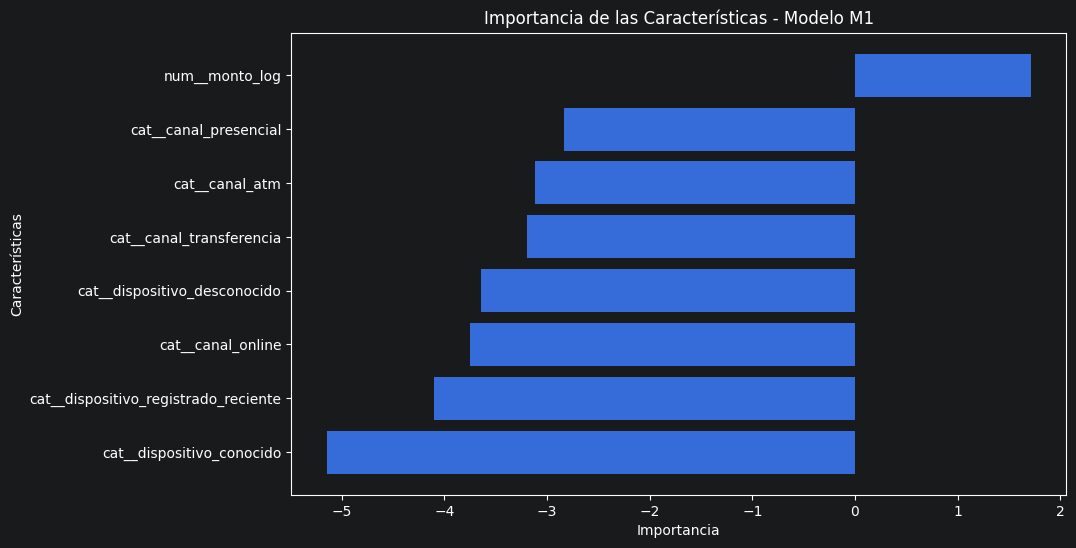

In [6]:
# Definir los nombres de los archivos que quieres buscar
nombres_modelos = [
    'M1_logistica.pkl'
]

modelos = [os.path.join(current_path, 'datos', 'v6', 'modelos', nombre) for nombre in nombres_modelos]
nombre_modelos = ['M1']

for m, n in zip(modelos, nombre_modelos):
    ruta_modelo = m
    nombre_modelo = n

    try:
        modelo = joblib.load(ruta_modelo)
        print("¡Modelo cargado exitosamente!")

    except FileNotFoundError:
        print(f"Error: No se encontró el archivo en la ruta '{ruta_modelo}'. Asegúrate de que el nombre y la ubicación sean correctos.")
    except Exception as e:
        print(f"Ocurrió un error al cargar el modelo: {e}")

    nombres_columnas = modelo["pipeline"]['pre'].get_feature_names_out().tolist()

    # 2. Extraer la importancia del modelo cargado
    importancias = modelo['pipeline']['clf'].coef_.tolist()[0]

    # 3. Crear un DataFrame para ordenarlas fácilmente
    df_importancia = pd.DataFrame({
        'Feature': nombres_columnas,
        'Importancia': importancias
    }).sort_values(by='Importancia', ascending=False)

    # 4. Graficarlo para verlo de un vistazo
    plt.figure(figsize=(10, 6))
    plt.barh(df_importancia['Feature'], df_importancia['Importancia']) # Invertido para que la más importante quede arriba
    plt.xlabel('Importancia')
    plt.ylabel('Características')
    plt.title(f'Importancia de las Características - Modelo {n}')
    plt.gca().invert_yaxis() # Pone la más importante arriba
    plt.show()

Sanity check para ver si lo reportado de TP, FP etc. está ok

In [5]:
import pickle
import pandas as pd
import os

# 1. Cargar M3
with open("v6/modelos/M3_gbm_completo.pkl", "rb") as f:
    m3 = pickle.load(f)

pipeline = m3["pipeline"]
features = m3["features"]
threshold = m3["threshold"]

# 2. Cargar operaciones completas
df = pd.read_parquet("operaciones.parquet") # Lo guardé en la current_path!

In [6]:
# Cargar validación T0
df_val_T0 = pd.read_parquet("operaciones_T0_valid.parquet") 
print(f"Operaciones en validación T0: {len(df_val_T0)}")

# Aplicar M3
proba = pipeline.predict_proba(df_val_T0[features])[:, 1]
pred = (proba >= threshold).astype(int)

# Conteos
y_true = df_val_T0["es_fraude"].values
TP = ((pred == 1) & (y_true == True)).sum()
FP = ((pred == 1) & (y_true == False)).sum()
FN = ((pred == 0) & (y_true == True)).sum()
TN = ((pred == 0) & (y_true == False)).sum()

f1 = 2 * TP / (2 * TP + FP + FN)
print(f"TP={TP}, FP={FP}, FN={FN}, TN={TN}")
print(f"F1 = {f1:.4f}  (debería dar ≈ 0.842)")

Operaciones en validación T0: 180832
TP=1176, FP=170, FN=272, TN=179214
F1 = 0.8418  (debería dar ≈ 0.842)


Check correcto

### Exploro el modelo

In [7]:
# Estructura general del pkl
print("Claves del dict:", m3.keys())
print("\nFeatures:", features)
print("Threshold óptimo (T0):", threshold)

# El pipeline en sí
print("\nPipeline:")
print(pipeline)

Claves del dict: dict_keys(['pipeline', 'features', 'threshold'])

Features: ['monto_log', 'secuencia_24h', 'terminal_risk_score', 'canal', 'dispositivo', 'hora_bin']
Threshold óptimo (T0): 0.46

Pipeline:
Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['monto_log', 'secuencia_24h',
                                                   'terminal_risk_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['canal', 'dispositivo',
                                                   'hora_bin'])])),
                ('clf',
                 GradientBoostingClassifier(learning_rate=0.08, max_depth=4,
                                            n_estimators=200,
                                            random_state=20260424,
                     

In [8]:
clf = pipeline.named_steps["clf"]
print("Hiperparámetros del GBM:")
for k, v in clf.get_params().items():
    print(f"  {k}: {v}")

Hiperparámetros del GBM:
  ccp_alpha: 0.0
  criterion: friedman_mse
  init: None
  learning_rate: 0.08
  loss: log_loss
  max_depth: 4
  max_features: None
  max_leaf_nodes: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 2
  min_weight_fraction_leaf: 0.0
  n_estimators: 200
  n_iter_no_change: None
  random_state: 20260424
  subsample: 0.8
  tol: 0.0001
  validation_fraction: 0.1
  verbose: 0
  warm_start: False


### Aplico el modelo al período 13 a 15

In [9]:
# Cargar T1 etiquetadas (subconjunto auditado)
df_T1_etiq = pd.read_parquet("operaciones_T1_etiquetadas.parquet")
print(f"Total T1 etiquetadas: {len(df_T1_etiq)}")
print(df_T1_etiq["mes"].value_counts().sort_index())

# Filtrar transición (meses 13-15)
df_transicion = df_T1_etiq[df_T1_etiq["mes"].between(13, 15)]
print(f"\nMeses 13-15 etiquetadas: {len(df_transicion)}")

# Aplicar M3
proba_t = pipeline.predict_proba(df_transicion[features])[:, 1]
pred_t = (proba_t >= threshold).astype(int)

y_true = df_transicion["es_fraude"].values
TP = ((pred_t == 1) & (y_true == True)).sum()
FP = ((pred_t == 1) & (y_true == False)).sum()
FN = ((pred_t == 0) & (y_true == True)).sum()
TN = ((pred_t == 0) & (y_true == False)).sum()

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nMeses 13-15 (transición), threshold = {threshold}")
print(f"TP={TP}, FP={FP}, FN={FN}, TN={TN}")
print(f"Precisión={precision:.3f}, Sensibilidad={recall:.3f}, F1={f1:.4f}")

Total T1 etiquetadas: 180365
mes
13    14588
14    15050
15    15260
16    15127
17    14565
18    14632
19    14319
20    15664
21    14699
22    15330
23    15993
24    15138
Name: count, dtype: int64

Meses 13-15 etiquetadas: 44898

Meses 13-15 (transición), threshold = 0.46
TP=192, FP=42, FN=249, TN=44415
Precisión=0.821, Sensibilidad=0.435, F1=0.5689


In [10]:
for m in [13, 14, 15]:
    df_m = df_T1_etiq[df_T1_etiq["mes"] == m]
    proba_m = pipeline.predict_proba(df_m[features])[:, 1]
    pred_m = (proba_m >= threshold).astype(int)
    y = df_m["es_fraude"].values
    TP = ((pred_m == 1) & (y == True)).sum()
    FP = ((pred_m == 1) & (y == False)).sum()
    FN = ((pred_m == 0) & (y == True)).sum()
    f1 = 2 * TP / (2 * TP + FP + FN) if (2*TP + FP + FN) > 0 else 0
    print(f"Mes {m}: n={len(df_m)}, F1={f1:.4f}")

Mes 13: n=14588, F1=0.6735
Mes 14: n=15050, F1=0.6312
Mes 15: n=15260, F1=0.3981


Coincide con lo reportado en la página de Anfora

### Analizamos el umbral, probamos con la ventana de 13 a 15 y nos quedamos con el que mejor da, luego lo testeamos con el período 16 a 18

Threshold óptimo en 13-15: 0.16, F1 = 0.6310
F1 en 16-18 con ese threshold: 0.1324
F1 en 16-18 con threshold original 0.46: 0.1024


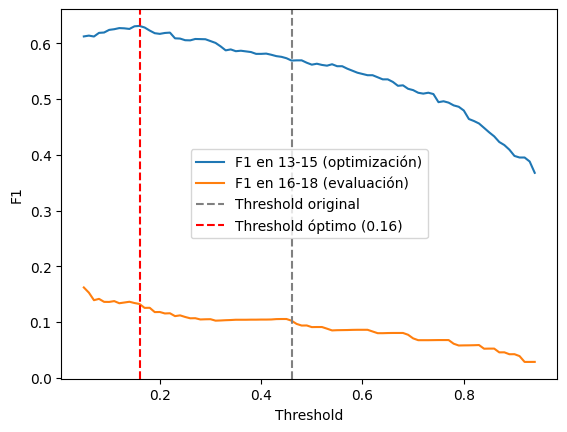

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datos: transición (13-15) para optimizar, ventana operativa (16-18) para evaluar
df_train = df_T1_etiq[df_T1_etiq["mes"].between(13, 15)]
df_test = df_T1_etiq[df_T1_etiq["mes"].between(16, 18)]

proba_train = pipeline.predict_proba(df_train[features])[:, 1]
proba_test = pipeline.predict_proba(df_test[features])[:, 1]
y_train = df_train["es_fraude"].values
y_test = df_test["es_fraude"].values

def f1_score(proba, y, u):
    pred = (proba >= u).astype(int)
    TP = ((pred == 1) & (y == True)).sum()
    FP = ((pred == 1) & (y == False)).sum()
    FN = ((pred == 0) & (y == True)).sum()
    return 2 * TP / (2 * TP + FP + FN) if (2*TP + FP + FN) > 0 else 0

umbrales = np.arange(0.05, 0.95, 0.01)
f1_train = [f1_score(proba_train, y_train, u) for u in umbrales]
f1_test = [f1_score(proba_test, y_test, u) for u in umbrales]

u_optimo = umbrales[np.argmax(f1_train)]
print(f"Threshold óptimo en 13-15: {u_optimo:.2f}, F1 = {max(f1_train):.4f}")
print(f"F1 en 16-18 con ese threshold: {f1_score(proba_test, y_test, u_optimo):.4f}")
print(f"F1 en 16-18 con threshold original 0.46: {f1_score(proba_test, y_test, 0.46):.4f}")

# Gráfico
plt.plot(umbrales, f1_train, label="F1 en 13-15 (optimización)")
plt.plot(umbrales, f1_test, label="F1 en 16-18 (evaluación)")
plt.axvline(0.46, color="gray", linestyle="--", label="Threshold original")
plt.axvline(u_optimo, color="red", linestyle="--", label=f"Threshold óptimo ({u_optimo:.2f})")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.legend()
plt.show()

Si bien mejora al elegir otro umbral, aún así el score F1 es muy bajo.   

### Probamos modificar el terminal risk score: versión original, verisón invertida, y versión 0,5 (como si no estuviera basicamente)

In [12]:
# Datos: ventana operativa (16-18)
df_eval = df_T1_etiq[df_T1_etiq["mes"].between(16, 18)].copy()
y_eval = df_eval["es_fraude"].values

def aplicar_y_medir(df_input, label):
    proba = pipeline.predict_proba(df_input[features])[:, 1]
    pred = (proba >= threshold).astype(int)
    TP = ((pred == 1) & (y_eval == True)).sum()
    FP = ((pred == 1) & (y_eval == False)).sum()
    FN = ((pred == 0) & (y_eval == True)).sum()
    TN = ((pred == 0) & (y_eval == False)).sum()
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f"{label}: TP={TP}, FP={FP}, FN={FN}, precisión={precision:.3f}, sensibilidad={recall:.3f}, F1={f1:.4f}")
    return f1

# 1. Original
f1_orig = aplicar_y_medir(df_eval, "Original          ")

# 2. Invertida
df_inv = df_eval.copy()
df_inv["terminal_risk_score"] = 1 - df_inv["terminal_risk_score"]
f1_inv = aplicar_y_medir(df_inv, "Invertida (1 - x)  ")

# 3. Neutralizada
df_neu = df_eval.copy()
df_neu["terminal_risk_score"] = 0.5
f1_neu = aplicar_y_medir(df_neu, "Neutralizada (0.5)")

Original          : TP=32, FP=51, FN=510, precisión=0.386, sensibilidad=0.059, F1=0.1024
Invertida (1 - x)  : TP=418, FP=32061, FN=124, precisión=0.013, sensibilidad=0.771, F1=0.0253
Neutralizada (0.5): TP=86, FP=98, FN=456, precisión=0.467, sensibilidad=0.159, F1=0.2369


La mejor es la versión neutralizada, basicamente es como el M2 o M4

### Un último análisis, referido al "delay de 7 días" en terminal risk score

In [13]:
df_t1 = df_T1_etiq.copy()

# Quintiles de terminal_risk_score (mismos cortes para todos los meses)
cortes = df_t1["terminal_risk_score"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).values
df_t1["quintil"] = pd.cut(df_t1["terminal_risk_score"], bins=cortes, include_lowest=True, labels=["Q1","Q2","Q3","Q4","Q5"])

# Para cada mes y quintil: ¿cuántos fraudes hay?
tabla = df_t1.groupby(["mes", "quintil"], observed=True).agg(
    n_ops=("es_fraude", "size"),
    n_fraudes=("es_fraude", "sum")
).reset_index()
tabla["pct_fraudes_de_total"] = tabla.groupby("mes")["n_fraudes"].transform(lambda x: x / x.sum() * 100)

# Pivot para ver mejor: en cada mes, qué porcentaje de los fraudes vienen de cada quintil
pivot = tabla.pivot(index="mes", columns="quintil", values="pct_fraudes_de_total")
print(pivot.round(1))

quintil    Q1    Q2    Q3    Q4    Q5
mes                                  
13        0.0   0.0   0.8   1.7  97.5
14        0.0   0.0   0.0   3.0  97.0
15        0.0   0.6   4.5   8.4  86.4
16        1.2   4.6   7.5  13.3  73.4
17        6.1   9.9  13.8  24.9  45.3
18       22.9  23.9  21.8  17.0  14.4
19       17.4  23.9  18.9  17.9  21.9
20       23.7  16.7  17.7  23.7  18.3
21       15.7  24.2  23.7  21.7  14.6
22       18.9  20.2  20.2  19.3  21.5
23       23.9  19.7  14.7  22.7  18.9
24       19.7  19.7  22.5  19.7  18.3


Nada, la variable terminal risk score deja de ser explicativa. 

### Ahora probamos reentrenar el modelo pero con el período operativo y buscar el umbral óptimo para cada uno de threshold

In [ ]:
import numpy as np
import pandas as pd

#función para rethinking 
def hpdi(samples, prob=0.95):
    sorted_samples = np.sort(samples)
    n = len(sorted_samples)
    interval_idx_inc = int(np.floor(prob * n))
    n_intervals = n - interval_idx_inc
    interval_width = sorted_samples[interval_idx_inc:] - sorted_samples[:n_intervals]
    min_idx = np.argmin(interval_width)
    return sorted_samples[min_idx], sorted_samples[min_idx + interval_idx_inc]

def evaluar_bayes(model, df_test, features, S=50000, seed=20260424):
    """
    Calcula F1 puntual, mediana posterior, HPDI 95%, conteos.
    Optimiza threshold en el F1 puntual y usa ese threshold para los conteos.
    """
    np.random.seed(seed)
    proba = model.predict_proba(df_test[features])[:, 1]
    y = df_test["es_fraude"].values
    
    # Buscar threshold óptimo
    mejor_f1, mejor_u = 0, 0
    for u in np.arange(0.05, 0.95, 0.01):
        pred = (proba >= u).astype(int)
        TP = ((pred == 1) & (y == True)).sum()
        FP = ((pred == 1) & (y == False)).sum()
        FN = ((pred == 0) & (y == True)).sum()
        if TP + FP > 0 and TP + FN > 0:
            f1 = 2 * TP / (2 * TP + FP + FN)
            if f1 > mejor_f1:
                mejor_f1, mejor_u = f1, u
    
    # Conteos finales con el mejor threshold
    pred = (proba >= mejor_u).astype(int)
    TP = int(((pred == 1) & (y == True)).sum())
    FP = int(((pred == 1) & (y == False)).sum())
    FN = int(((pred == 0) & (y == True)).sum())
    
    # Posteriores Beta-Binomial
    muestras_p = np.random.beta(1 + TP, 1 + FP, S)
    muestras_r = np.random.beta(1 + TP, 1 + FN, S)
    muestras_f1 = 2 * muestras_p * muestras_r / (muestras_p + muestras_r)
    
    mediana = np.median(muestras_f1)
    hpdi_inf, hpdi_sup = hpdi(muestras_f1, prob=0.95)
    
    return {
        "F1_puntual": mejor_f1,
        "threshold": mejor_u,
        "TP": TP, "FP": FP, "FN": FN,
        "F1_mediana": mediana,
        "HPDI_95_inf": hpdi_inf,
        "HPDI_95_sup": hpdi_sup,
        "muestras_f1": muestras_f1
    }

# Aplicar a cada modelo
resultados = {}
filas = []
for nombre, cfg in config.items():
    pipe = construir_pipeline(cfg["features"], cfg["clf"])
    pipe.fit(df_train[cfg["features"]], df_train["es_fraude"])
    res = evaluar_bayes(pipe, df_test, cfg["features"])
    resultados[nombre] = res
    filas.append({
        "modelo": nombre,
        "F1_puntual": round(res["F1_puntual"], 4),
        "F1_mediana": round(res["F1_mediana"], 4),
        "HPDI_95": f"[{res['HPDI_95_inf']:.4f}, {res['HPDI_95_sup']:.4f}]",
        "conteos": f"TP={res['TP']}, FP={res['FP']}, FN={res['FN']}",
        "threshold": round(res["threshold"], 2)
    })

df_reporte = pd.DataFrame(filas)
print(df_reporte.to_string(index=False))

          modelo  F1_puntual  F1_mediana          HPDI_95               conteos  threshold
    M1_logistica      0.4800      0.4789 [0.4298, 0.5272]  TP=96, FP=116, FN=92       0.18
M2_random_forest      0.4368      0.4357 [0.3845, 0.4890]  TP=76, FP=84, FN=112       0.43
 M3_gbm_completo      0.4642      0.4631 [0.4157, 0.5129]  TP=94, FP=123, FN=94       0.12
 M4_gbm_moderado      0.5269      0.5252 [0.4749, 0.5759]   TP=98, FP=86, FN=90       0.25
  M5_naive_bayes      0.2194      0.2201 [0.1842, 0.2570] TP=61, FP=307, FN=127       0.08


Puede observarse que el modelo M4 predomina frente al resto, seguido por M1 y luego por M3.

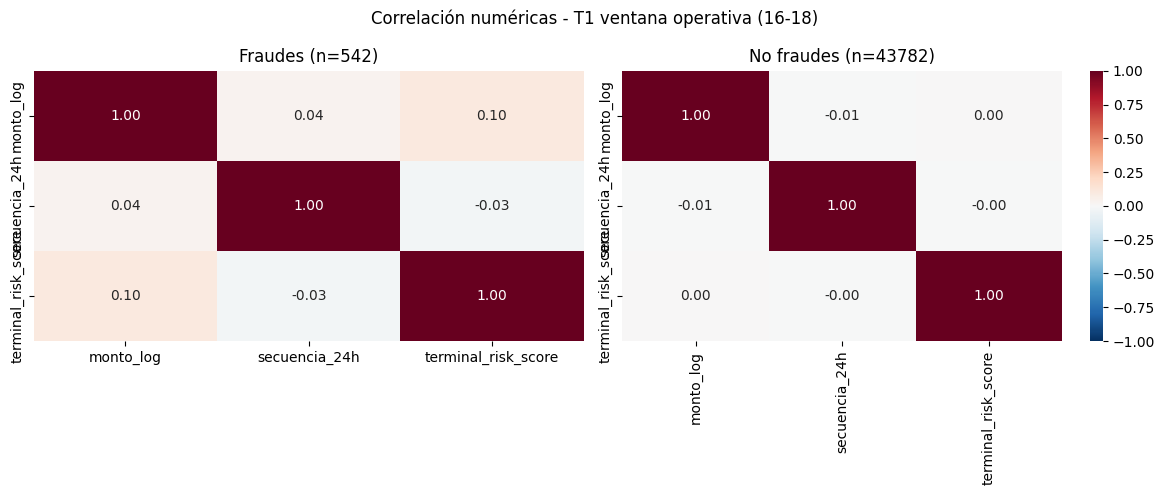

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar T1 ventana operativa (meses 16-18) etiquetadas
df_op = df_T1_etiq[df_T1_etiq["mes"].between(16, 18)].copy()
df_fraudes = df_op[df_op["es_fraude"] == True]
df_nofraudes = df_op[df_op["es_fraude"] == False]

features_num = ["monto_log", "secuencia_24h", "terminal_risk_score"]
features_cat = ["canal", "dispositivo", "hora_bin"]

# ============================
# 1. Correlación numéricas
# ============================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

corr_fraudes = df_fraudes[features_num].corr()
corr_nofraudes = df_nofraudes[features_num].corr()

sns.heatmap(corr_fraudes, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title(f"Fraudes (n={len(df_fraudes)})")

sns.heatmap(corr_nofraudes, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title(f"No fraudes (n={len(df_nofraudes)})")

plt.suptitle("Correlación numéricas - T1 ventana operativa (16-18)")
plt.tight_layout()
plt.show()

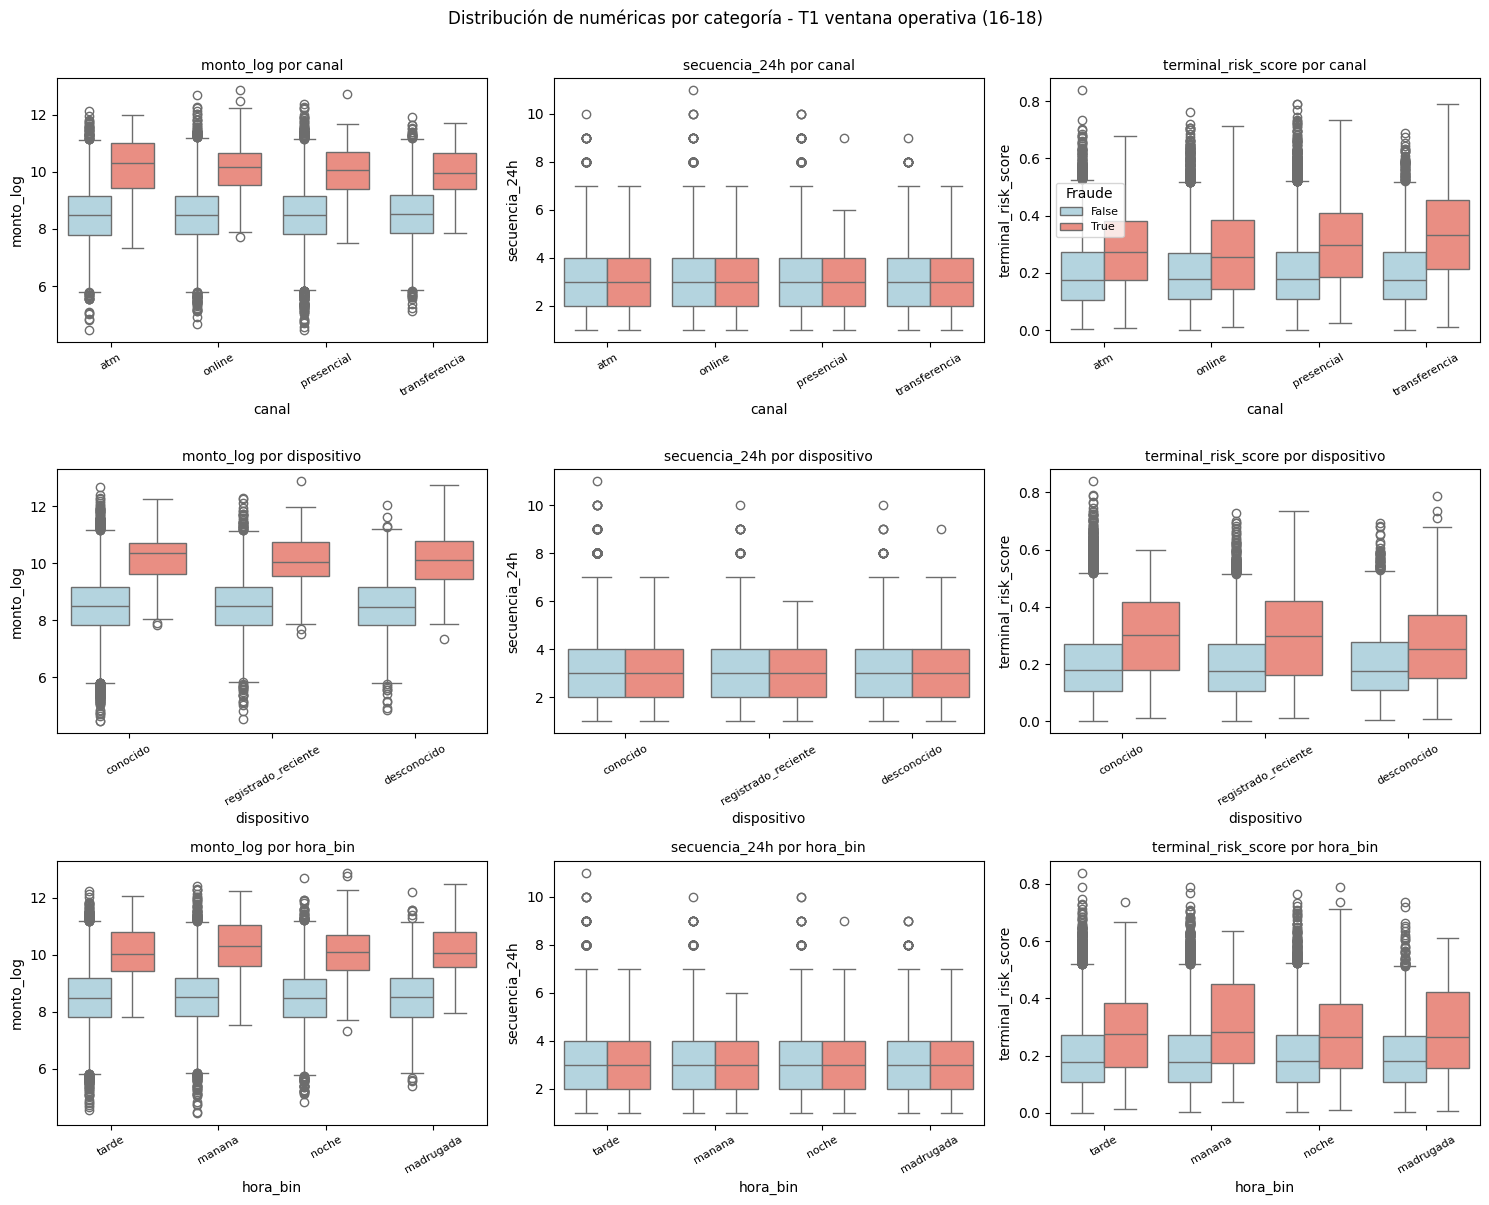

In [16]:
# ============================
# 2. Numéricas por categoría (boxplots)
# ============================
fig, axes = plt.subplots(len(features_cat), len(features_num), figsize=(15, 12))

for i, cat in enumerate(features_cat):
    for j, num in enumerate(features_num):
        ax = axes[i, j]
        sns.boxplot(data=df_op, x=cat, y=num, hue="es_fraude", ax=ax, palette={False: "lightblue", True: "salmon"})
        ax.set_title(f"{num} por {cat}", fontsize=10)
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        if i == 0 and j == len(features_num)-1:
            ax.legend(title="Fraude", fontsize=8)
        else:
            ax.get_legend().remove()

plt.suptitle("Distribución de numéricas por categoría - T1 ventana operativa (16-18)", y=1.00)
plt.tight_layout()
plt.show()

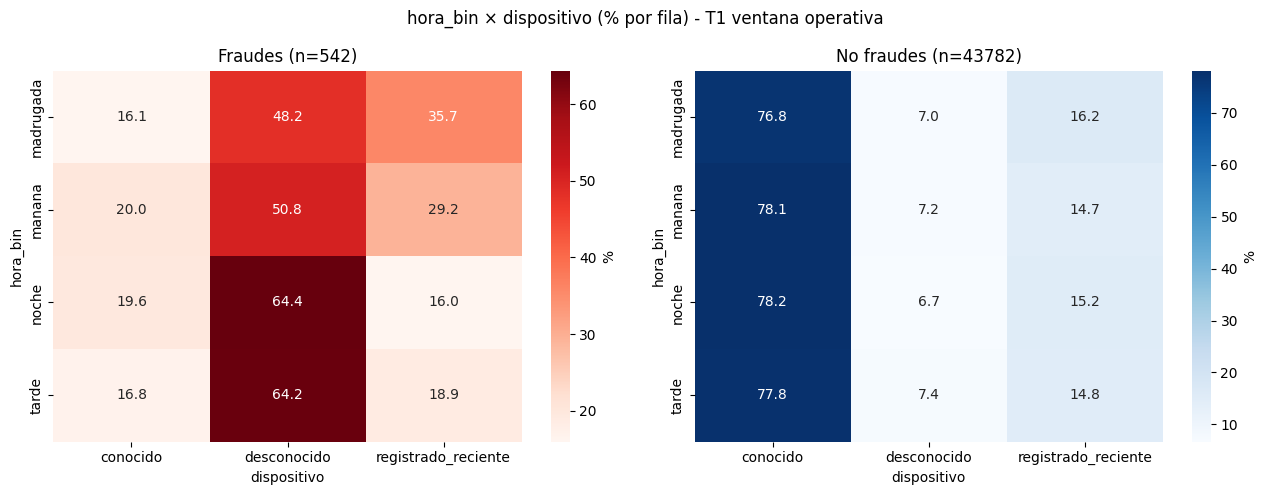

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar T1 ventana operativa
df_op = df_T1_etiq[df_T1_etiq["mes"].between(16, 18)].copy()
df_fraudes = df_op[df_op["es_fraude"] == True]
df_nofraudes = df_op[df_op["es_fraude"] == False]

# Tablas de contingencia normalizadas (porcentaje dentro de cada hora_bin)
tabla_fraudes = pd.crosstab(df_fraudes["hora_bin"], df_fraudes["dispositivo"], normalize="index") * 100
tabla_nofraudes = pd.crosstab(df_nofraudes["hora_bin"], df_nofraudes["dispositivo"], normalize="index") * 100

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(tabla_fraudes, annot=True, fmt=".1f", cmap="Reds", ax=axes[0], cbar_kws={"label": "%"})
axes[0].set_title(f"Fraudes (n={len(df_fraudes)})")

sns.heatmap(tabla_nofraudes, annot=True, fmt=".1f", cmap="Blues", ax=axes[1], cbar_kws={"label": "%"})
axes[1].set_title(f"No fraudes (n={len(df_nofraudes)})")

plt.suptitle("hora_bin × dispositivo (% por fila) - T1 ventana operativa")
plt.tight_layout()
plt.show()